# Pradeep kumar

## System Capacity & Care Load Analytics for Unaccompanied Children

# 1: Project Introduction

# Objective #
### To analyze capacity utilization, care load pressure,
### backlog accumulation, and future demand within the
### CBP-HHS child care pipeline.

# Goals
### 1. Monitor Total System Load
### 2. Detect Capacity Stress
### 3. Analyze Intake vs Discharge
### 4. Forecast Future Demand
### 5. Support Policy Decisions

# 2: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

# 3: Load Dataset

In [2]:
df = pd.read_csv (r"C:\Users\prade\projects\HHS_Unaccompanied_Alien_Children_Program.csv")

In [3]:
df.head(11)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0
5,"December 14, 2025",8.0,35.0,4.0,"2,462",8.0
6,"December 11, 2025",7.0,47.0,9.0,"2,437",10.0
7,"December 10, 2025",10.0,54.0,5.0,"2,439",9.0
8,"December 09, 2025",4.0,30.0,7.0,"2,443",8.0
9,"December 08, 2025",9.0,27.0,9.0,"2,440",4.0


### Check shape

In [4]:
df.shape

(1170, 6)

### Check columns

In [5]:
df.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

### Convert date

In [6]:

df["Date"] = pd.to_datetime(df["Date"])

### Sort

In [7]:
df = df.sort_values("Date")

# 4: Data Cleaning & Validation

### Remove Spaces and commas from Column Names

In [8]:
df.columns = df.columns.str.strip()

#### Missing Values

In [9]:
print(df.isnull().sum())

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


### Convert Numeric Columns

In [10]:
numeric_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in numeric_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

### Convert Date Column

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

### missing dates

In [12]:
full_dates = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(df["Date"])

print(missing_dates)

DatetimeIndex(['2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-26',
               ...
               '2025-11-22', '2025-11-26', '2025-11-28', '2025-11-29',
               '2025-12-05', '2025-12-06', '2025-12-12', '2025-12-13',
               '2025-12-19', '2025-12-20'],
              dtype='datetime64[ns]', length=355, freq=None)


### Fill Missing Dates Value #

In [13]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Date"] = df["Date"].fillna(method="ffill")

df["Date"] = df["Date"].fillna(method="bfill")

### verify

In [14]:
print(df.isnull().sum())

Date                                                 0
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


#### Replace missing values with  median  Because(Use Median better than Mean for time-series.) ###
#### (Mode is generally not recommended for continuous numerical time-series data because it may repeat a single value too often.) ###
#### (If there are spikes or outliers in care load data, median is more robust.) ###

In [15]:
df[col].fillna(
        df[col].median(),
        inplace=True
    )

In [16]:
print(df.isnull().sum())

Date                                                 0
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                    0
dtype: int64


#### Fill Any Remaining Missing Values WITH MEAN

In [17]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

### verify

In [18]:
print(df.isnull().sum())

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


### Check Duplicate Rows

In [19]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 449


### Remove duplicates rows

In [20]:
df = df.drop_duplicates()

### verify

In [21]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


## Validation Rules

### Transfers ≤ CBP

In [22]:
df[
    df["Children transferred out of CBP custody"] >
    df["Children in CBP custody"]
]

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
716,2023-01-24,47.0,42.0,47.0,7433.0,175.0
715,2023-01-25,20.0,22.0,41.0,7538.0,180.0
710,2023-02-02,15.0,13.0,23.0,7879.0,298.0
697,2023-02-22,107.0,215.0,230.0,7978.0,232.0
696,2023-02-23,101.0,162.0,178.0,7914.0,386.0
...,...,...,...,...,...,...
217,2025-01-30,47.0,42.0,47.0,3923.0,159.0
216,2025-02-02,20.0,22.0,41.0,3483.0,168.0
211,2025-02-09,15.0,13.0,23.0,2878.0,99.0
207,2025-02-13,15.0,10.0,23.0,2703.0,72.0


### Discharge ≤ HHS

In [23]:
df[
    df["Children discharged from HHS Care"] >
    df["Children in HHS Care"]
    ]

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care


# 5: Feature Engineering

### Create metrics.

In [24]:
df["Total_System_Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

In [25]:
df["Net_Intake"] = (
    df["Children transferred out of CBP custody"]
    -
    df["Children discharged from HHS Care"]
)

In [26]:
df["Growth_Rate"] = (
    df["Total_System_Load"]
    .pct_change()*100
)

In [27]:
df["Backlog"] = (
    df["Net_Intake"]
    .cumsum()
)

In [28]:
df["Discharge_Offset_Ratio"] = (
    df["Children discharged from HHS Care"]
    /
    df["Children transferred out of CBP custody"]
)

# 6: Exploratory Data Analysis

## Visualization 1

### Daily Apprehensions


In [29]:
fig = px.line(
    df,
    x="Date",
    y="Children apprehended and placed in CBP custody*",
    title="Daily Apprehensions Trend"
)

fig.show()

## Visualization 2

### CBP vs HHS Load

In [30]:
fig = px.line(
    df,
    x="Date",
    y=[
        "Children in CBP custody",
        "Children in HHS Care"
    ],
    title="CBP vs HHS Load"
)

fig.show()

## Visualization 3

### Total System Load

In [31]:
fig = px.area(
    df,
    x="Date",
    y="Total_System_Load",
    title="Total System Load"
)

fig.show()

## Visualization 4

### Net Intake Pressure

In [32]:
fig = px.bar(
    df,
    x="Date",
    y="Net_Intake",
    title="Net Intake Pressure"
)

fig.show()

## Visualization 5

### Backlog Trend

In [33]:
fig = px.line(
    df,
    x="Date",
    y="Backlog",
    title="Backlog Accumulation"
)

fig.show()

## Visualization 6

### Correlation Heatmap

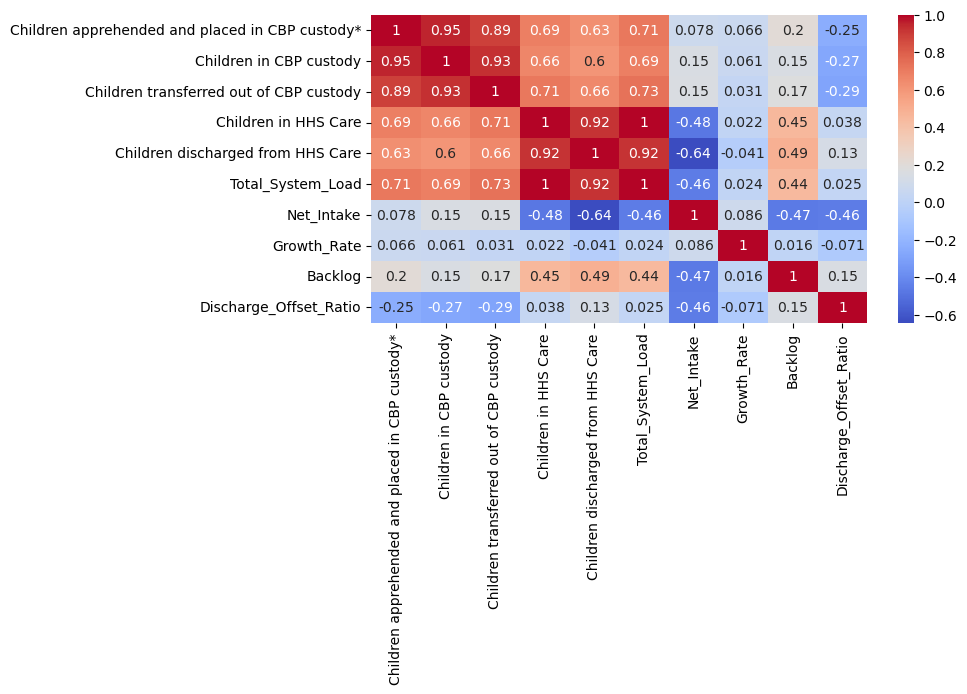

In [34]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.select_dtypes(include=np.number)
      .corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# 7: KPI Analysis

### Latest KPIs

In [35]:
latest_load = df["Total_System_Load"].iloc[-1]

latest_backlog = df["Backlog"].iloc[-1]

latest_pressure = df["Net_Intake"].iloc[-1]

volatility = df["Total_System_Load"].std()

offset = (
    df["Discharge_Offset_Ratio"]
    .mean()
)

### Display

In [36]:
print("Total Load:", latest_load)
print("Backlog:", latest_backlog)
print("Net Intake:", latest_pressure)
print("Volatility:", volatility)
print("Offset Ratio:", offset)

Total Load: 6232.769444444444
Backlog: -32264.331944444446
Net Intake: -52.331944444444446
Volatility: 2916.430667053998
Offset Ratio: inf


# 8: Capacity Stress Analysis

## Rolling averages


In [37]:
df["Load_7D"] = (
    df["Total_System_Load"]
    .rolling(7)
    .mean()
)

In [38]:
df["Load_14D"] = (
    df["Total_System_Load"]
    .rolling(14)
    .mean()
)

### Plot

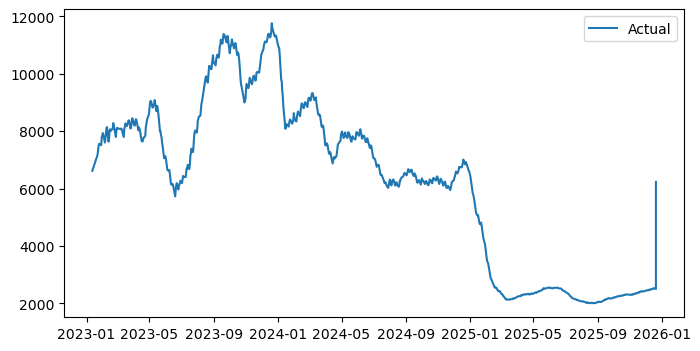

In [39]:
plt.figure(figsize=(8,4))
plt.plot(
    df["Date"],
    df["Total_System_Load"],
    label="Actual"
)
plt.legend()

plt.show()

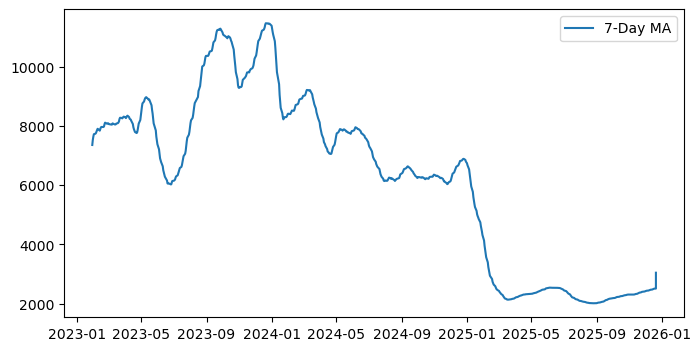

In [40]:
plt.figure(figsize=(8,4))
plt.plot(
    df["Date"],
    df["Load_7D"],
    label="7-Day MA"
)
plt.legend()

plt.show()

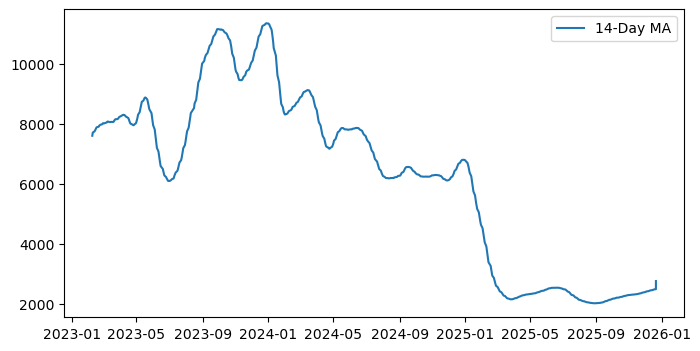

In [41]:
plt.figure(figsize=(8,4))
plt.plot(
    df["Date"],
    df["Load_14D"],
    label="14-Day MA"
)

plt.legend()

plt.show()

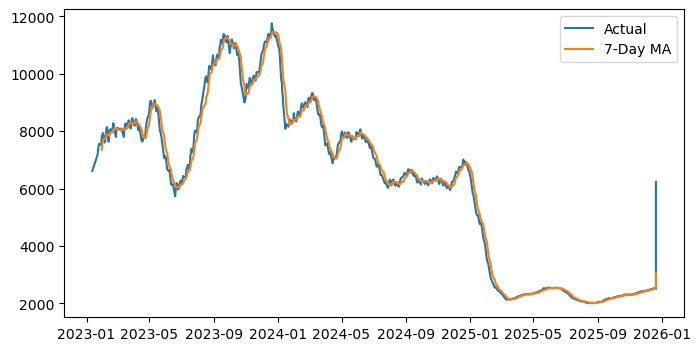

In [42]:
plt.figure(figsize=(8,4))

plt.plot(
    df["Date"],
    df["Total_System_Load"],
    label="Actual"
)
plt.plot(
    df["Date"],
    df["Load_7D"],
    label="7-Day MA"
)
plt.legend()

plt.show()

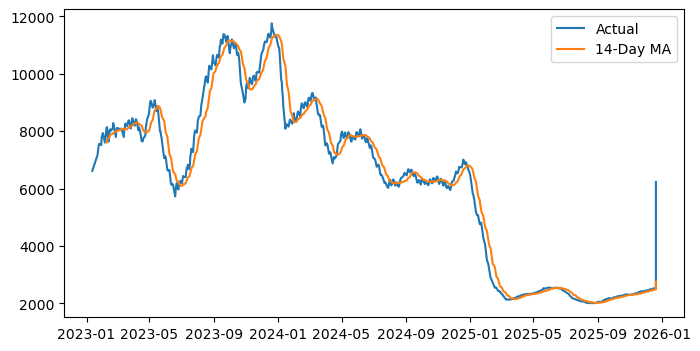

In [43]:
plt.figure(figsize=(8,4))

plt.plot(
    df["Date"],
    df["Total_System_Load"],
    label="Actual"
)
plt.plot(
    df["Date"],
    df["Load_14D"],
    label="14-Day MA"
)
plt.legend()

plt.show()

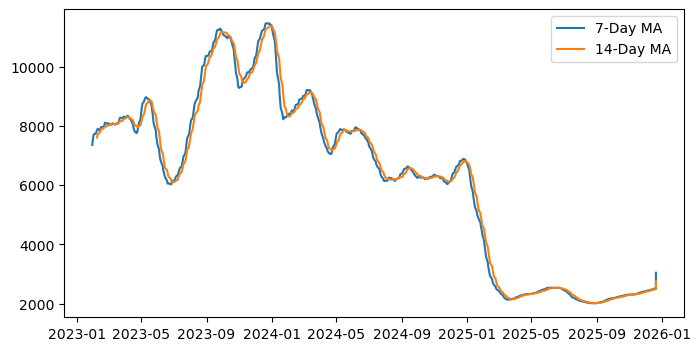

In [44]:
plt.figure(figsize=(8,4))

plt.plot(
    df["Date"],

    df["Load_7D"],
    label="7-Day MA"
)
plt.plot(
    df["Date"],
    df["Load_14D"],
    label="14-Day MA"
)
plt.legend()

plt.show()

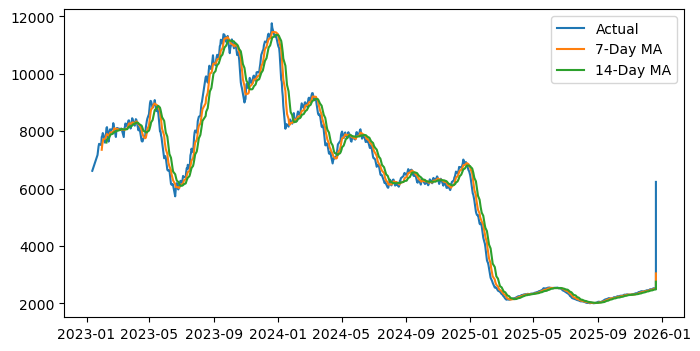

In [45]:
plt.figure(figsize=(8,4))

plt.plot(
    df["Date"],
    df["Total_System_Load"],
    label="Actual"
)

plt.plot(
    df["Date"],
    df["Load_7D"],
    label="7-Day MA"
)

plt.plot(
    df["Date"],
    df["Load_14D"],
    label="14-Day MA"
)

plt.legend()

plt.show()

# 9: Anomaly Detection

In [46]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["Anomaly"] = iso.fit_predict(
    df[["Total_System_Load"]]
)

In [47]:
#Anomalies:
anomalies = df[
    df["Anomaly"] == -1
]

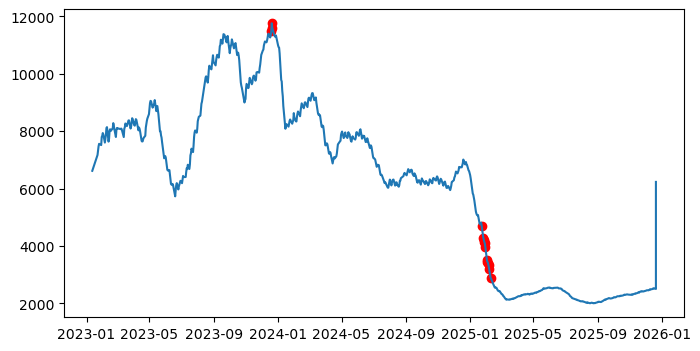

In [48]:
# Plot:

plt.figure(figsize=(8,4))

plt.plot(
    df["Date"],
    df["Total_System_Load"]
)

plt.scatter(
    anomalies["Date"],
    anomalies["Total_System_Load"],
    color="red"
)

plt.show()

# 10: Forecasting (ARIMA)

### Split data

In [49]:
train_size = len(df)-30

train = df.iloc[:train_size]

test = df.iloc[train_size:]

### Model

In [50]:
model = ARIMA(
    train["Total_System_Load"],
    order=(5,1,0)
)

model_fit = model.fit()

### Forecast

In [51]:
forecast = model_fit.forecast(
    steps=len(test)
)

### Accuracy

In [52]:
rmse = np.sqrt(
    mean_squared_error(
        test["Total_System_Load"],
        forecast
    )
)

print("RMSE:",rmse)

RMSE: 737.6020564482783


### plot

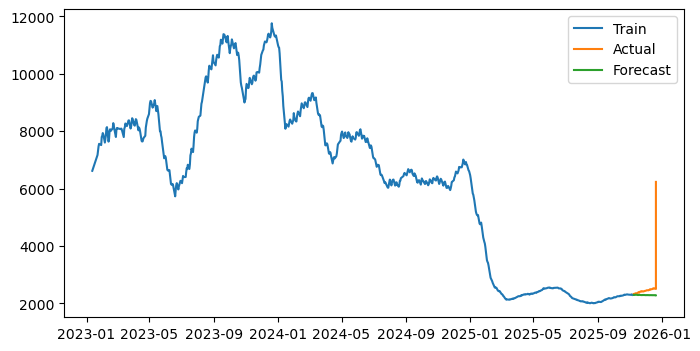

In [53]:
plt.figure(figsize=(8,4))

plt.plot(
    train["Date"],
    train["Total_System_Load"],
    label="Train"
)

plt.plot(
    test["Date"],
    test["Total_System_Load"],
    label="Actual"
)

plt.plot(
    test["Date"],
    forecast,
    label="Forecast"
)

plt.legend()

plt.show()

# Future 90-Day Forecast

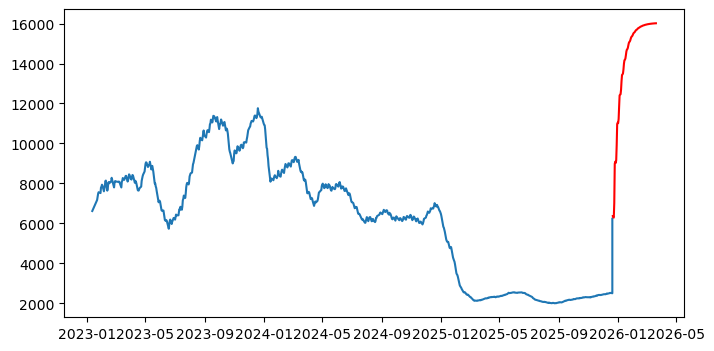

In [54]:
final_model = ARIMA(
    df["Total_System_Load"],
    order=(5,1,0)
)

final_fit = final_model.fit()
future = final_fit.forecast(
    steps=90
)
future_dates = pd.date_range(
    start=df["Date"].max(),
    periods=91,
    freq="D"
)[1:]
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future
})
plt.figure(figsize=(8,4))

plt.plot(
    df["Date"],
    df["Total_System_Load"]
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    color="red"
)

plt.show()

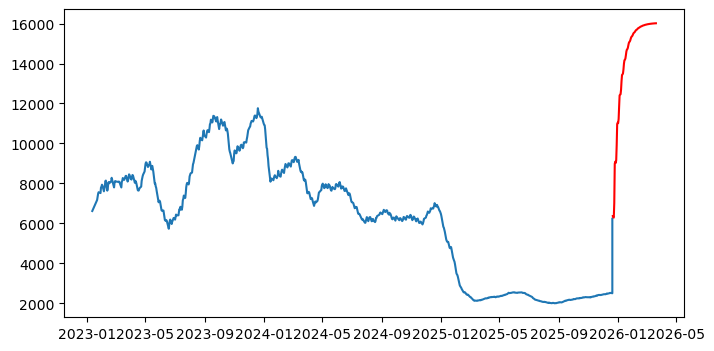

In [55]:
future = final_fit.forecast(
    steps=90
)

future_dates = pd.date_range(
    start=df["Date"].max(),
    periods=91,
    freq="D"
)[1:]

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future
})
plt.figure(figsize=(8,4))

plt.plot(
    df["Date"],
    df["Total_System_Load"]
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    color="red"
)

plt.show()

# 11: Recommendations
##  Recommendations
### 1. Increase staffing during predicted peaks.
### 2. Expand temporary shelter capacity during positive backlog growth.
### 3. Trigger alerts when 7-day average exceeds 90th percentile.
### 4. Improve discharge processing when offset ratio falls below 1.

# 12: Conclusion
### The UAC Care Load Analytics framework successfully monitors system load,backlog accumulation,capacity stress, and future demand.

### Forecasting and anomaly detection support proactive decision-making, enabling HHS and CBP stakeholders to allocate resources efficiently and reduce operational strain
## Key Visualizations Required in the Final Report
### Daily Apprehensions Trend 
### CBP vs HHS Load Comparison 
### Total System Load Area Chart 
### Net Intake Pressure Chart 
### Backlog Growth Trend ###
### Correlation Heatmap 
### Rolling Average Stress Analysis
### Anomaly Detection Plot 
### 90-Day Future Forecast

# Export Final Dataset

In [56]:
df.to_csv(
    "System Capacity & Care Load Analytics for Unaccompanied Children.csv"
)